# Section 5.3 - Probe Learning Curves Across Checkpoints

Figure 3 summarizes plasticity loss as a single scalar (final probe loss minus initial probe loss). Section 5.3 goes one level deeper: instead of only reporting the *final* probe loss, it records the entire probe-optimization trajectory for checkpoints saved at different points in DQN training. If plasticity is being lost gradually, later checkpoints should fit the same random-target probe more slowly, or plateau at a worse final loss, and that should be visible directly in the shape of the loss curve — not just in a single end-of-training number.

This notebook trains one DQN agent, saves checkpoints at a handful of training steps, and re-runs the plasticity probe on each checkpoint while logging the loss every few probe-optimizer steps.

In [1]:
import os
from pathlib import Path

import src

ROOT = Path(src.__file__).resolve().parent.parent
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
CHECKPOINTS_DIR = OUTPUT_ROOT / "checkpoints"
for directory in (OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

ROOT

PosixPath('/Users/mahdigheidi/Documents/Univ/Masters-Study-Project')

## Imports

`run_dqn_training` (shared DQN loop) already supports saving checkpoints at arbitrary steps via `checkpoint_steps`, so this notebook only needs to add the probe-learning-curve logic on top: `probe_learning_curves` from `src.experiments.plasticity` records the loss at every `log_every`-th probe step instead of only the final value.

In [2]:
from dataclasses import dataclass, replace
from typing import Dict, Optional, Sequence

import pandas as pd

from src.experiments.dqn_classification import (
    DEVICE,
    ClassificationDQNConfig,
    optimizer_factory_from_config,
    run_dqn_training,
)
from src.experiments.plasticity import PlasticityProbeConfig, probe_learning_curves

DEVICE

device(type='cpu')

## Run Configuration

`CheckpointCurveConfig` adds the set of training steps at which to snapshot the model (`checkpoint_steps`) and the probe budget used to trace out each checkpoint's learning curve (`probe_steps`, `num_probe_tasks`, `probe_batch_size`, `curve_log_every`).

In [3]:
@dataclass
class CheckpointCurveConfig(ClassificationDQNConfig):
    checkpoint_steps: Sequence[int] = (0, 5_000, 20_000)
    probe_steps: int = 2_000
    num_probe_tasks: int = 10
    probe_batch_size: int = 512
    curve_log_every: int = 50


def with_checkpoint_steps(
    config: CheckpointCurveConfig,
    checkpoint_steps: Sequence[int],
) -> CheckpointCurveConfig:
    return replace(config, checkpoint_steps=tuple(checkpoint_steps))

## Train, Checkpoint, and Probe

`run_checkpoint_curve_experiment` trains a DQN agent with `run_dqn_training`, which snapshots the model at every step in `config.checkpoint_steps`. It then samples one probe batch from the final replay buffer and runs the random-target probe on every checkpoint against that same batch, logging the loss every `curve_log_every` probe steps so the full optimization trajectory (not just the endpoint) is recorded.

In [4]:
def run_checkpoint_curve_experiment(
    config: CheckpointCurveConfig,
    save_path: Optional[str] = None,
) -> pd.DataFrame:
    training = run_dqn_training(config, checkpoint_steps=config.checkpoint_steps, device=DEVICE)
    replay = training["replay"]
    model_factory = training["model_factory"]
    checkpoints: Dict[str, object] = {
        f"step_{step}": model.to(DEVICE) for step, model in training["checkpoints"].items()
    }
    inputs = replay.sample_states(config.probe_batch_size, device=DEVICE)
    probe_config = PlasticityProbeConfig(
        steps=config.probe_steps,
        num_tasks=config.num_probe_tasks,
        batch_size=config.probe_batch_size,
        log_every=config.curve_log_every,
    )
    rows = probe_learning_curves(
        checkpoints, model_factory, inputs, optimizer_factory_from_config(config), probe_config,
    )
    df = pd.DataFrame(rows)
    df.insert(0, "architecture", config.architecture)
    df.insert(0, "environment", config.environment)
    df.insert(0, "observation_space", config.observation_space)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved checkpoint probe curves to {save_path}")

    return df

## Smoke vs. Paper-Like Configuration

`make_smoke_config` trains for 1,000 steps with three cheap checkpoints so the whole pipeline runs in seconds. `make_paper_like_config` matches the paper's scale: 100,000 training steps with checkpoints at 0, 5k, 20k, and 100k steps.

In [5]:
def make_smoke_config(data_root: str = "./data", download: bool = False) -> CheckpointCurveConfig:
    return CheckpointCurveConfig(
        data_root=data_root,
        download=download,
        observation_space="mnist",
        environment="easy",
        architecture="mlp",
        hidden_dim=128,
        batch_size=128,
        replay_capacity=5_000,
        warmup_steps=512,
        train_steps=1_000,
        target_update_period=250,
        checkpoint_steps=(0, 500, 1_000),
        probe_steps=100,
        num_probe_tasks=2,
        probe_batch_size=128,
        curve_log_every=10,
    )


def make_paper_like_config(
    data_root: str = "./data",
    download: bool = False,
    architecture: str = "mlp",
    environment: str = "easy",
) -> CheckpointCurveConfig:
    return CheckpointCurveConfig(
        data_root=data_root,
        download=download,
        observation_space="mnist",
        environment=environment,
        architecture=architecture,
        hidden_dim=512,
        train_steps=100_000,
        target_update_period=1_000,
        checkpoint_steps=(0, 5_000, 20_000, 100_000),
        probe_steps=2_000,
        num_probe_tasks=10,
        probe_batch_size=512,
        curve_log_every=50,
    )

In [6]:
cfg = make_smoke_config(data_root=str(DATA_ROOT), download=False)
cfg

CheckpointCurveConfig(seed=0, data_root='/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', download=False, observation_space='mnist', environment='easy', architecture='mlp', hidden_dim=128, cnn_channels=64, cnn_fc_dim=256, gamma=0.99, lr=0.001, optimizer='adam', weight_decay=0.0, batch_size=128, replay_capacity=5000, warmup_steps=512, train_steps=1000, target_update_period=250, epsilon_start=1.0, epsilon_final=0.1, epsilon_decay=10000, use_layernorm=False, spectral_norm=False, shrink_perturb_every=None, shrink=0.4, perturb=0.1, reset_last_layer_every=None, checkpoint_steps=(0, 500, 1000), probe_steps=100, num_probe_tasks=2, probe_batch_size=128, curve_log_every=10)

In [7]:
curve_path = TABLES_DIR / "figure4_checkpoint_probe_curves.csv"
curves = run_checkpoint_curve_experiment(cfg, save_path=curve_path)

curves.head()

Running random probe task with 100 steps and batch size 128.
Random targets generated with shape torch.Size([128, 10]).



  0%|          | 0/100 [00:00<?, ?it/s]


100%|██████████| 100/100 [00:00<00:00, 2196.12it/s]

Running random probe task with 100 steps and batch size 128.
Random targets generated with shape torch.Size([128, 10]).



  0%|          | 0/100 [00:00<?, ?it/s]

...

Running random probe task with 100 steps and batch size 128.
Random targets generated with shape torch.Size([128, 10]).



  0%|          | 0/100 [00:00<?, ?it/s]


100%|██████████| 100/100 [00:00<00:00, 2720.50it/s]

Saved checkpoint probe curves to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/tables/figure4_checkpoint_probe_curves.csv


,observation_space,environment,architecture,checkpoint,task_id,step,loss,final_loss
0,mnist,easy,mlp,step_0,0.0,0.0,0.498871,0.0012
1,mnist,easy,mlp,step_0,0.0,10.0,0.405210,0.0012
2,mnist,easy,mlp,step_0,0.0,20.0,0.282216,0.0012
3,mnist,easy,mlp,step_0,0.0,30.0,0.165230,0.0012
4,mnist,easy,mlp,step_0,0.0,40.0,0.083505,0.0012


## Summarize Final Probe Loss by Checkpoint

A quick scalar summary before looking at the full curves: mean final probe loss per checkpoint. This is the same quantity Figure 3 reports (just without the intermediate baseline subtraction).

In [8]:
curves.groupby("checkpoint", as_index=False)["final_loss"].mean()

,checkpoint,final_loss
0,step_0,0.001007
1,step_1000,0.010005
2,step_500,0.002214


## Plot Learning Curves

The full picture: probe loss over the course of probe optimization, one line per DQN checkpoint. A widening gap between early and late checkpoints (slower descent, or a higher plateau) is the signature of plasticity loss.

In [9]:
def plot_checkpoint_learning_curves(df: pd.DataFrame, save_path=None):
    import matplotlib.pyplot as plt

    grouped = (
        df.groupby(["checkpoint", "step"], as_index=False)["loss"]
        .mean()
        .sort_values(["checkpoint", "step"])
    )
    fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)

    for checkpoint, group in grouped.groupby("checkpoint"):
        ax.plot(group["step"], group["loss"], linewidth=2.0, label=checkpoint)

    ax.set_title("Probe learning curves by DQN checkpoint")
    ax.set_xlabel("Probe optimizer step")
    ax.set_ylabel("MSE to random target")
    ax.grid(True, linewidth=0.6, alpha=0.5)
    ax.legend(title="Checkpoint")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved checkpoint curve figure to {save_path}")

    return fig

Saved checkpoint curve figure to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/figures/figure4_checkpoint_probe_curves.png


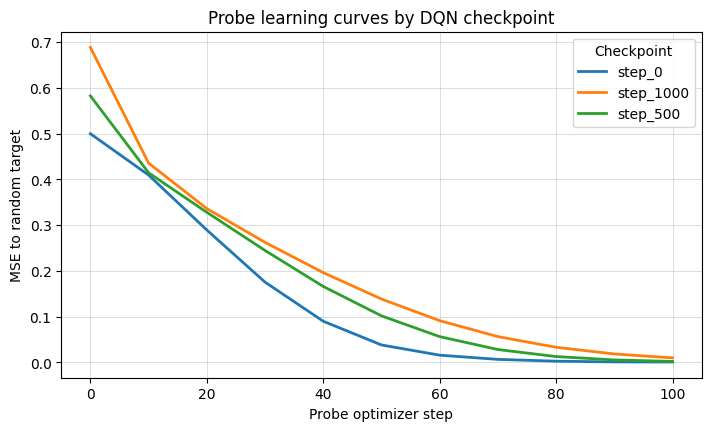

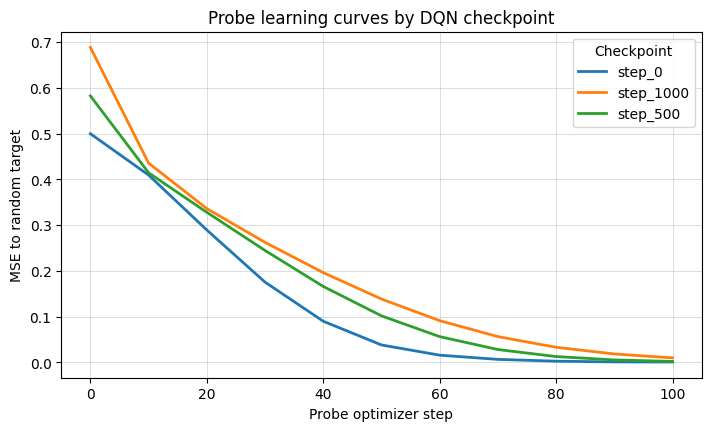

In [10]:
figure_path = FIGURES_DIR / "figure4_checkpoint_probe_curves.png"
fig = plot_checkpoint_learning_curves(curves, save_path=figure_path)
fig

## Paper-Like Starting Point

Uncomment to train for 100,000 steps with paper-scale checkpoints (0, 5k, 20k, 100k). This is substantially slower than the smoke run above; `with_checkpoint_steps` is a convenience for trying other checkpoint schedules without rebuilding the whole config.

In [11]:
# paper_cfg = make_paper_like_config(
#     data_root=str(DATA_ROOT), download=False, architecture="mlp", environment="easy",
# )
# paper_curves = run_checkpoint_curve_experiment(
#     paper_cfg, save_path=TABLES_DIR / "figure4_checkpoint_probe_curves_paper.csv"
# )
# plot_checkpoint_learning_curves(paper_curves)